# EDA: House Prices (Ames Housing)

## Цель: понять таргет `SalePrice`, распределение пропусков, связи
ключевых признаков, и показать, что уходит в модель после
`src.features.build_housing_features` + `TabularPreprocessor`.
Моделирование и подбор гиперпараметров - в `Modeling_Housing.ipynb`.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

_current = Path.cwd().resolve()
for _p in [_current, *_current.parents]:
    if (_p / "src").exists():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        PROJECT_ROOT = _p
        break
else:
    raise RuntimeError("Не нашёл корень проекта (папку с src/)")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import get_config
from src.features import build_housing_features, TabularPreprocessor
from src.utils import set_seed

set_seed(42)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 200)


config = get_config("housing")
TARGET = config["target"]      # SalePrice
ID_COL = config["id_column"]   # Id
print("target:", TARGET, "| id:", ID_COL)
print("train_path:", config["data"]["train_path"])
print("test_path: ", config["data"]["test_path"])
print("log_target:", config["features"].get("log_target"))

PROJECT_ROOT = C:\Users\xmxlx\Desktop\Final Project
target: SalePrice | id: Id
train_path: C:\Users\xmxlx\Desktop\Final Project\data\housing\train_housing.csv
test_path:  C:\Users\xmxlx\Desktop\Final Project\data\housing\test_housing.csv
log_target: True


In [2]:
train_df = pd.read_csv(config["data"]["train_path"])
test_df = pd.read_csv(config["data"]["test_path"])
print(f"train: {train_df.shape}, test: {test_df.shape}")
df = train_df.copy()

train: (1460, 81), test: (1459, 80)


## 1. Общая статистика

In [3]:
df.info()

display(df.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallCond    1460

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


## 2. Таргет SalePrice
Ожидаем правостороннюю скошенность (mean > median). В конфиге
`features.log_target: true` — препроцессор применит `np.log1p`.

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


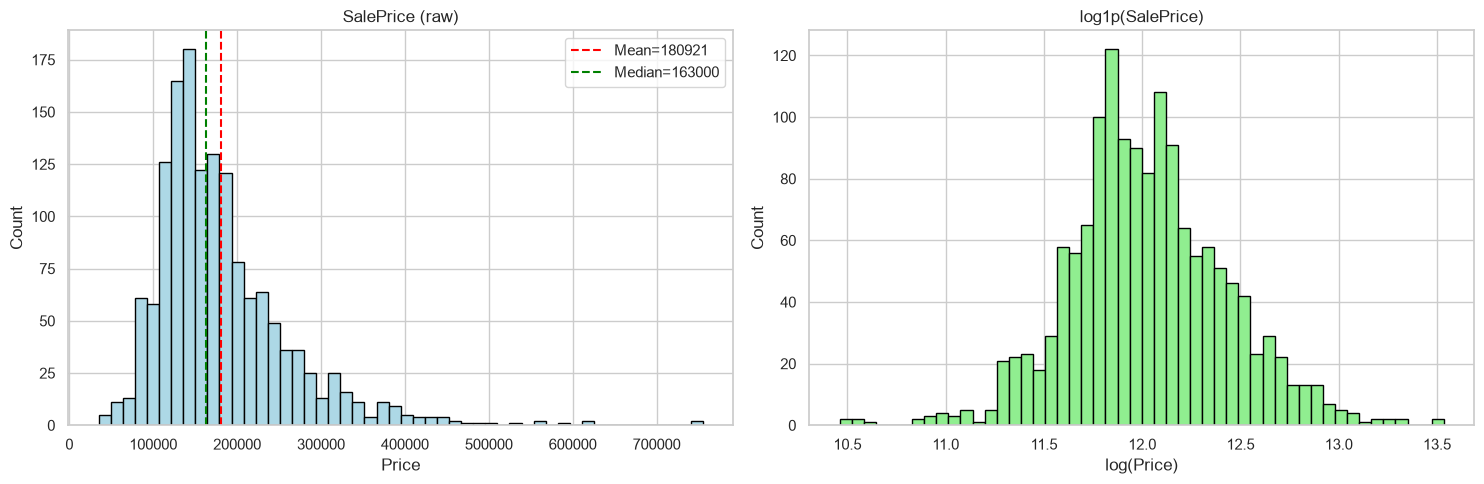

In [4]:
print(df[TARGET].describe())

# %%
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(df[TARGET], bins=50, color="lightblue", edgecolor="black")
axes[0].axvline(df[TARGET].mean(),   color="red",   ls="--", label=f"Mean={df[TARGET].mean():.0f}")
axes[0].axvline(df[TARGET].median(), color="green", ls="--", label=f"Median={df[TARGET].median():.0f}")
axes[0].set_title("SalePrice (raw)")
axes[0].set_xlabel("Price")
axes[0].set_ylabel("Count")
axes[0].legend()

axes[1].hist(np.log1p(df[TARGET]), bins=50, color="lightgreen", edgecolor="black")
axes[1].set_title("log1p(SalePrice)")
axes[1].set_xlabel("log(Price)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

## **Вывод:** сырое распределение скошено вправо (mean ≈ 180k > median ≈ 163k),
разброс от 35k до 755k. `log1p` делает распределение близким к нормальному -
в конфиге это уже включено (`log_target: true`).

## 3. Пропуски
В `configs/housing.yaml` прописаны стратегии:
- `none_categorical` - заполняем "None" (это «нет фичи», не отсутствие данных)
- `none_numeric` - заполняем 0
- `group_median: LotFrontage by Neighborhood`
- `fillna: Electrical => mode`

Колонок с пропусками: 19
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


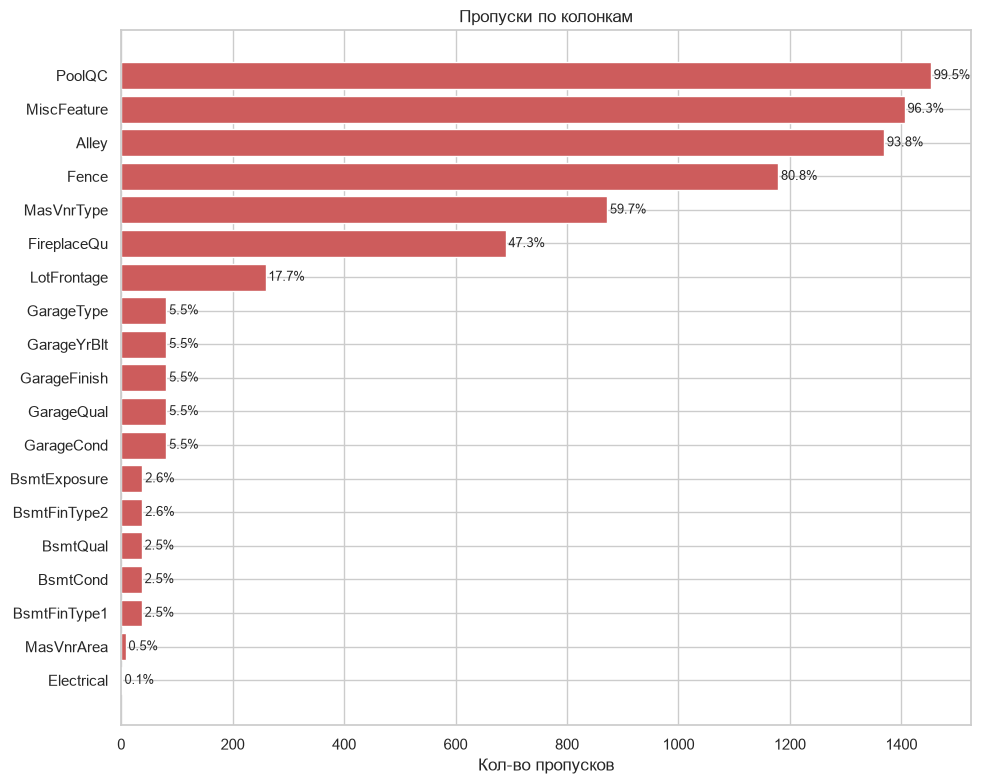

none_categorical: ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']
none_numeric:     ['MasVnrArea', 'GarageYrBlt', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
group_median:     {'LotFrontage': 'Neighborhood'}
fillna:           {'Electrical': 'mode'}


In [5]:
missing = df.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f"Колонок с пропусками: {len(missing)}")
print(missing)

plt.figure(figsize=(10, 8))
bars = plt.barh(missing.index[::-1], missing.values[::-1], color="indianred")
for bar, cnt in zip(bars, missing.values[::-1]):
    pct = cnt / len(df) * 100
    plt.text(bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
             f"{pct:.1f}%", va="center", fontsize=9)
plt.title("Пропуски по колонкам")
plt.xlabel("Кол-во пропусков")
plt.tight_layout()
plt.show()

# сверим с конфигом: какие колонки-«нет фичи» уже перечислены
cfg_feat = config["features"]
print("none_categorical:", cfg_feat.get("none_categorical"))
print("none_numeric:    ", cfg_feat.get("none_numeric"))
print("group_median:    ", cfg_feat.get("group_median"))
print("fillna:          ", cfg_feat.get("fillna"))

# **Вывод:** 19 колонок с пропусками. Большинство - это категориальные
«нет фичи» (PoolQC, MiscFeature, Alley, Fence, ...) => заполняются строкой
`"None"`, а не удаляются. Реальные пропуски: `LotFrontage` (~18%,
заполняется медианой по `Neighborhood`), `Electrical` (1 шт → mode).
Стратегии уже описаны в конфиге.

## 4. Корреляции: числовые признаки

Топ-10 числовых по |corr| с SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
Name: SalePrice, dtype: float64


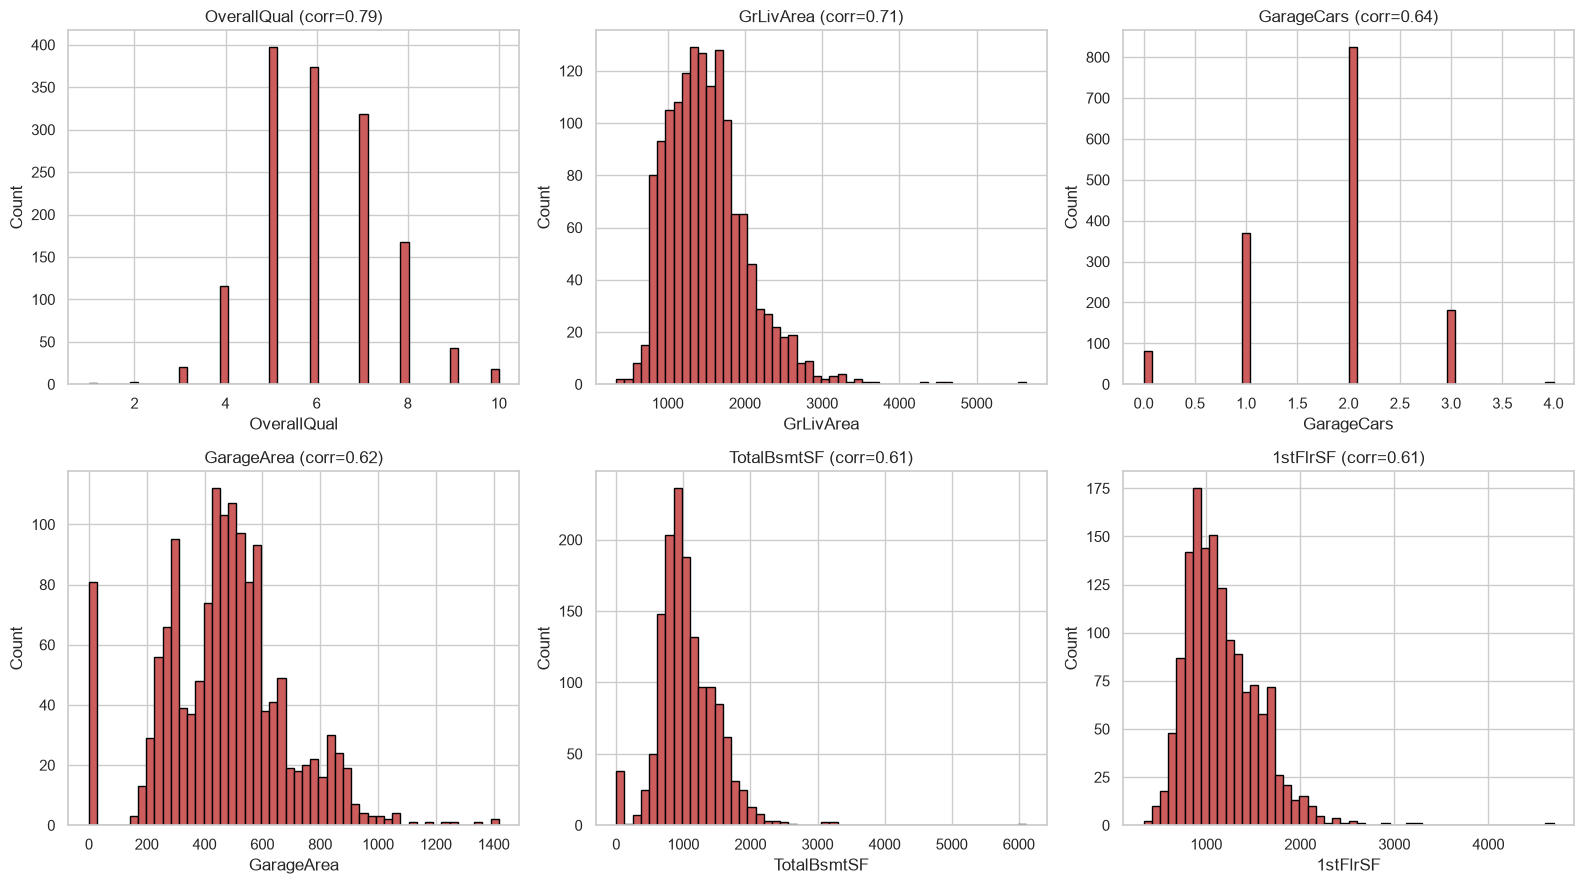

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_with_target = df[numeric_cols].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

top_numeric = corr_with_target.head(10)
print("Топ-10 числовых по |corr| с SalePrice:")
print(top_numeric)

# %%
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for i, col in enumerate(top_numeric.index[:6]):
    axes[i].hist(df[col].dropna(), bins=50, color="indianred", edgecolor="black")
    axes[i].set_title(f"{col} (corr={top_numeric[col]:.2f})")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
plt.tight_layout()
plt.show()


# **Вывод:** сильнейшие числовые — `OverallQual` (0.79), `GrLivArea` (0.71),
`GarageCars` (0.64), `GarageArea` (0.62), `TotalBsmtSF` (0.61), `1stFlrSF` (0.61).
`OverallQual` - дискретный (1–10), остальные непрерывные. `GrLivArea` и
`TotalBsmtSF` скошены - FE частично это лечит (`TotalSF`, `TotalBath`, ...).

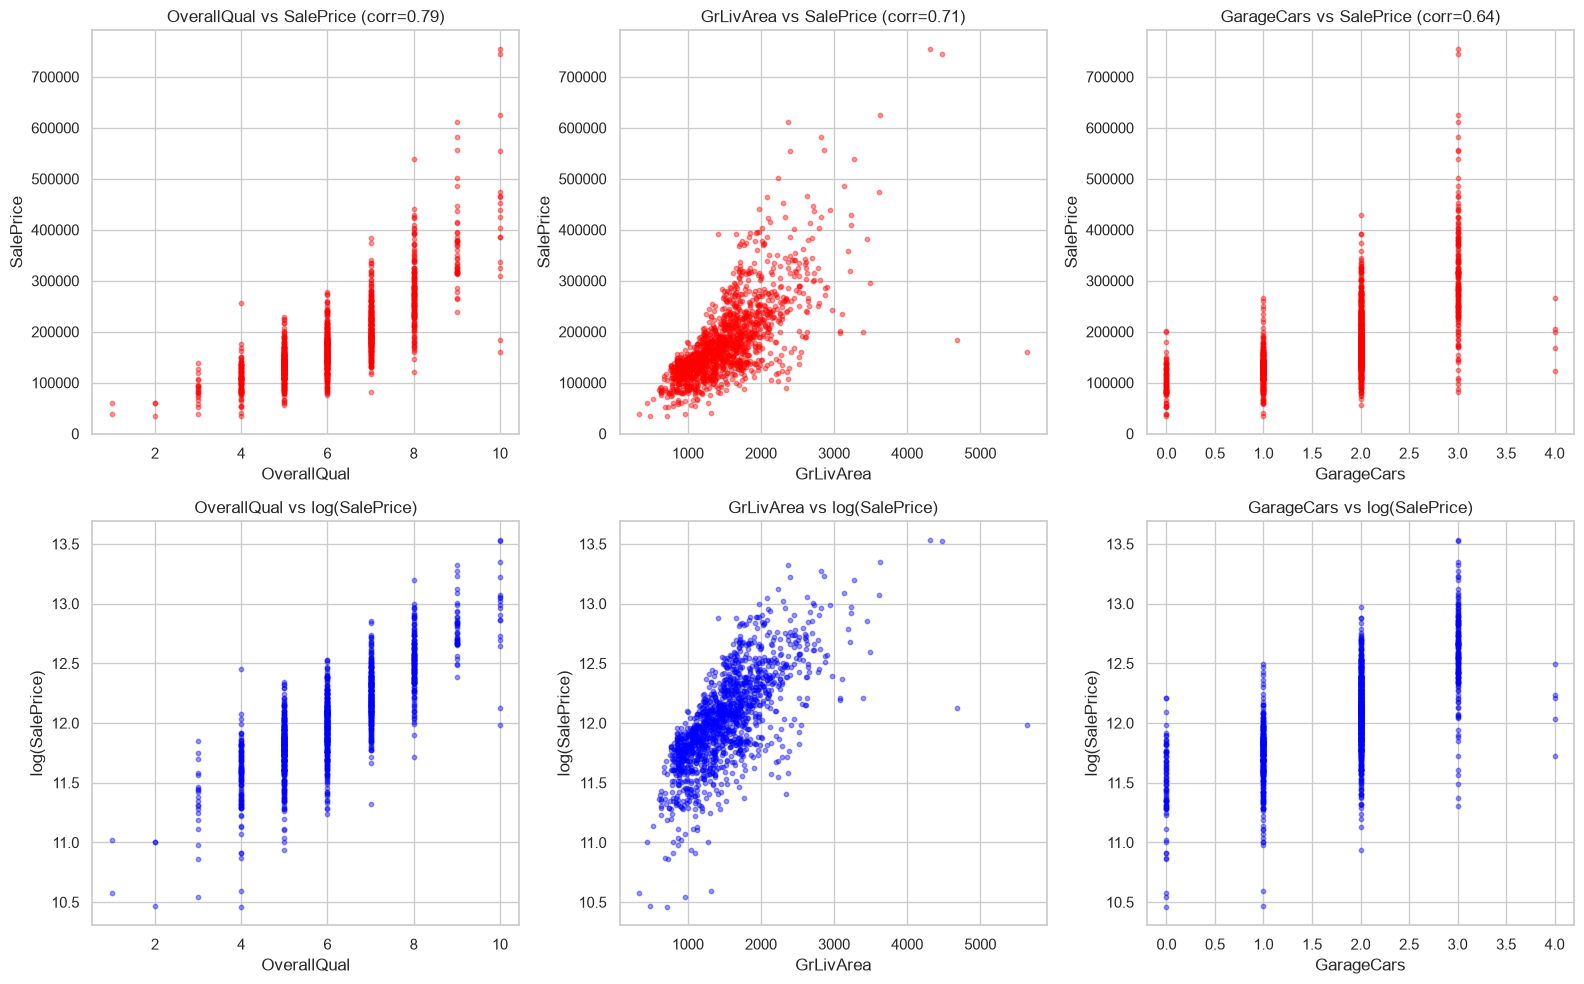

In [7]:
# SalePrice vs top-3 - до и после log
top3 = corr_with_target.head(3).index.tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for i, col in enumerate(top3):
    axes[0, i].scatter(df[col], df[TARGET], alpha=0.4, s=10, color="red")
    axes[0, i].set_title(f"{col} vs SalePrice (corr={corr_with_target[col]:.2f})")
    axes[0, i].set_xlabel(col); axes[0, i].set_ylabel("SalePrice")

    axes[1, i].scatter(df[col], np.log1p(df[TARGET]), alpha=0.4, s=10, color="blue")
    axes[1, i].set_title(f"{col} vs log(SalePrice)")
    axes[1, i].set_xlabel(col); axes[1, i].set_ylabel("log(SalePrice)")
plt.tight_layout()
plt.show()

## 5. Корреляции: категориальные признаки

Чтобы оценить связь категориальных с таргетом, кодируем их
`astype("category").cat.codes` **на копии**, иначе сломаем исходный df.

Категориальных колонок: 43
Топ-10 категориальных по |corr|:
ExterQual       0.636884
BsmtQual        0.611179
KitchenQual     0.589189
GarageFinish    0.513105
HeatingQC       0.400178
Foundation      0.382479
GarageType      0.358279
MasVnrType      0.308384
BsmtExposure    0.285290
LotShape        0.255580
dtype: float64


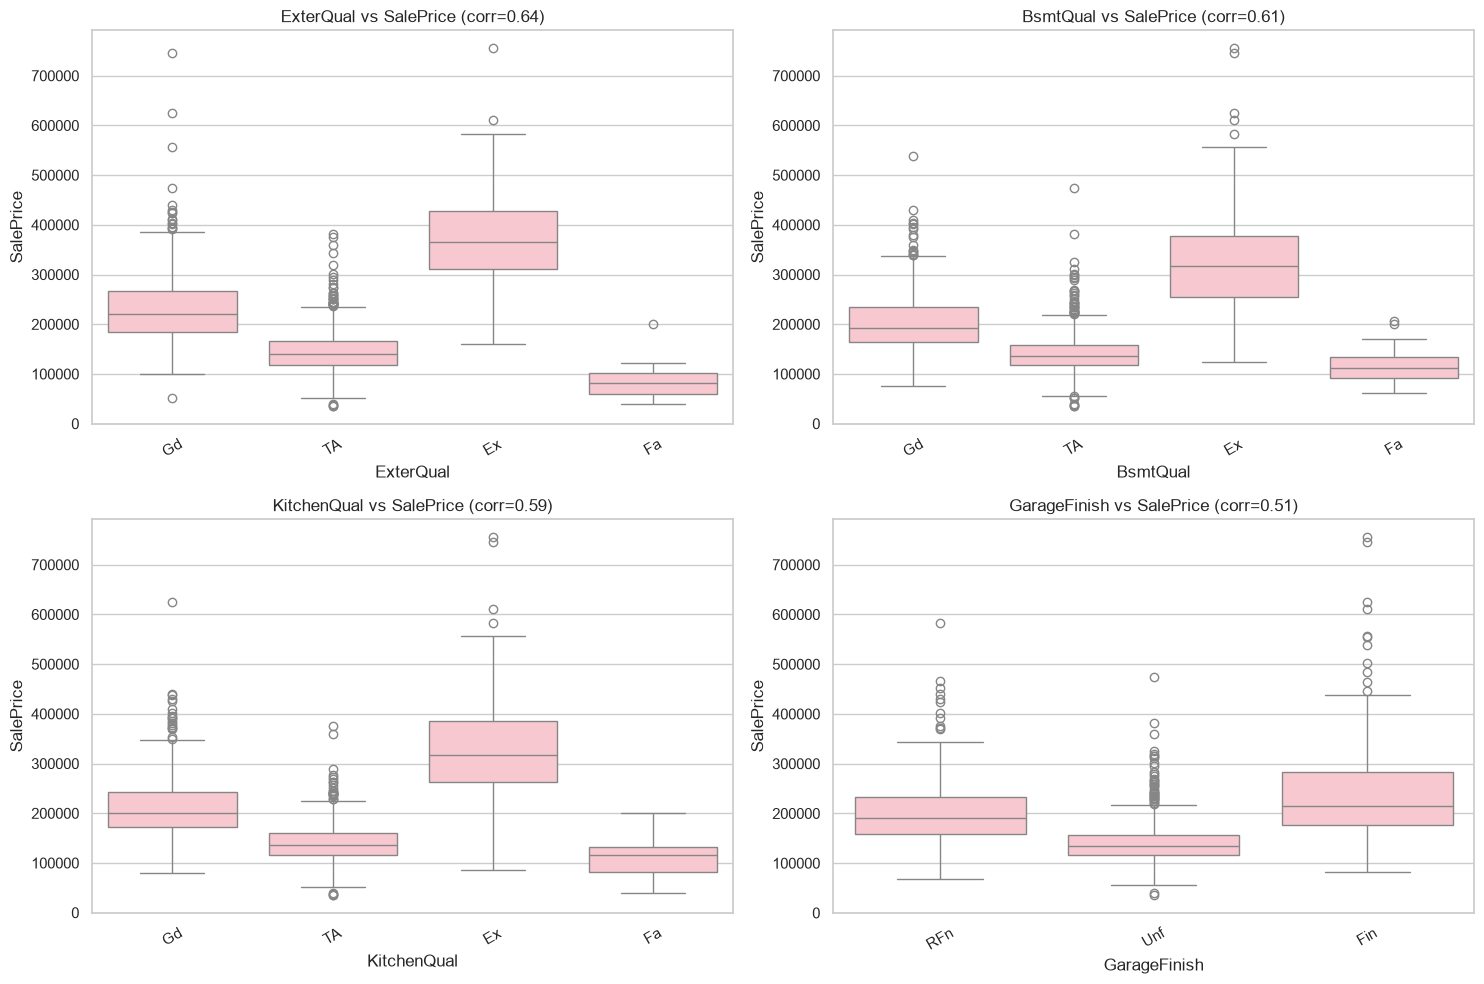

In [8]:
cat_cols = df.select_dtypes(include=["object", "string"]).columns
print(f"Категориальных колонок: {len(cat_cols)}")

cat_corr = {}
for col in cat_cols:
    if df[col].notna().sum() <= 100:
        continue
    tmp = df[[col, TARGET]].dropna().copy()
    tmp[col] = tmp[col].astype("category").cat.codes
    cat_corr[col] = abs(tmp[col].corr(tmp[TARGET]))

cat_corr = pd.Series(cat_corr).sort_values(ascending=False)
print("Топ-10 категориальных по |corr|:")
print(cat_corr.head(10))

# %%
top_cat = cat_corr.head(4).index.tolist()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()
for i, col in enumerate(top_cat):
    sns.boxplot(data=df, x=col, y=TARGET, ax=axes[i], color="pink")
    axes[i].set_title(f"{col} vs SalePrice (corr={cat_corr[col]:.2f})")
    axes[i].tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

# **Вывод:** топ категориальных — `ExterQual` (0.64), `BsmtQual` (0.61),
`KitchenQual` (0.59), `GarageFinish` (0.51). Все они - **порядковые**
(Po < Fa < TA < Gd < Ex), в конфиге уже перечислены в `features.ordinal`.
One-Hot для них потерял бы порядок, поэтому в проекте - ordinal encoding.

## 6. Feature engineering + препроцессинг

 FE — `build_housing_features` из `src.features` (используется и в `main.py`).

In [9]:
df_fe = build_housing_features(train_df)
new_cols = sorted(set(df_fe.columns) - set(train_df.columns))
print(f"До FE:  {train_df.shape}")
print(f"После FE: {df_fe.shape}")
print("Новые колонки:", new_cols)

# %%
prep = TabularPreprocessor(config)
X_all = prep.fit_transform(df_fe)
X_test_all = prep.transform(build_housing_features(test_df))
y_all = prep.transform_target(df_fe[TARGET])

print(f"X (train): {X_all.shape}")
print(f"X (test):  {X_test_all.shape}")
print(f"y (train): {y_all.shape}  | log-трансформация: {config['features'].get('log_target')}")
print(f"Колонок после OHE + FE: {X_all.shape[1]}")
print("Пример имён колонок:", list(X_all.columns)[:15])

До FE:  (1460, 81)
После FE: (1460, 91)
Новые колонки: ['Age', 'Has2ndFloor', 'HasBsmt', 'HasGarage', 'HasPool', 'OverallQuality', 'RemodAge', 'TotalBath', 'TotalRooms', 'TotalSF']
X (train): (1460, 90)
X (test):  (1459, 90)
y (train): (1460,)  | log-трансформация: True
Колонок после OHE + FE: 90
Пример имён колонок: ['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2']


c:\Users\xmxlx\Desktop\Final Project\.venv\Lib\site-packages\sklearn\preprocessing\_encoders.py:262: UserWarning: Found unknown categories in columns [0, 5, 15, 16, 27] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


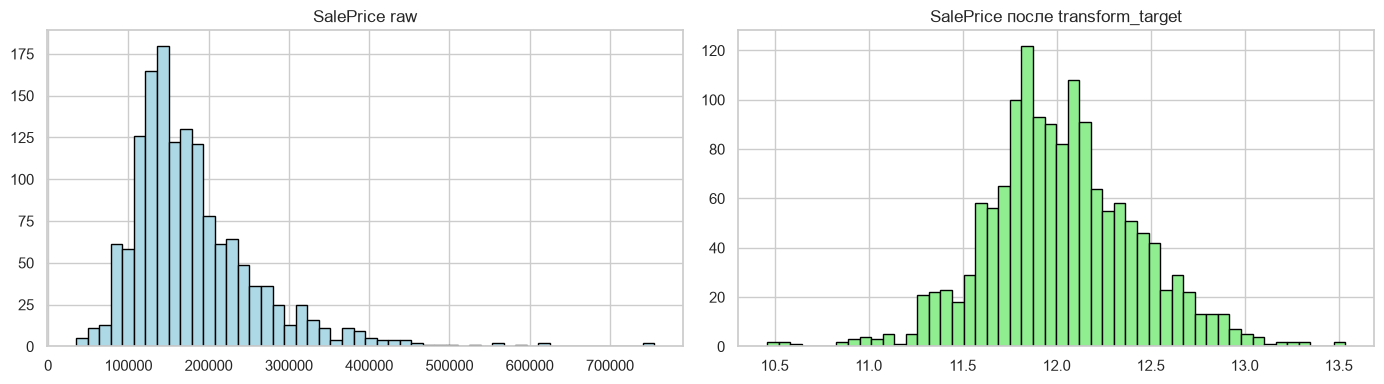

In [10]:
# распределение y после лог-трансформации (её делает препроцессор)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df_fe[TARGET], bins=50, color="lightblue", edgecolor="black")
axes[0].set_title("SalePrice raw")
axes[1].hist(y_all, bins=50, color="lightgreen", edgecolor="black")
axes[1].set_title("SalePrice после transform_target")
plt.tight_layout()
plt.show()

## 7. Выводы EDA

1. **Таргет:** правосторонняя скошенность; `log_target: true` в конфиге — оправдано.
2. **Пропуски:** 19 колонок. Большинство — «нет фичи» => в конфиге `none_categorical`/`none_numeric`.
    Реальные: `LotFrontage` (медиана по `Neighborhood`), `Electrical` (mode).
3. **Топ числовых:** `OverallQual`, `GrLivArea`, `GarageCars`, `GarageArea`, `TotalBsmtSF`.
4. **Топ категориальных:** `ExterQual`, `BsmtQual`, `KitchenQual`, `GarageFinish` — все порядковые => `features.ordinal`.
5. **FE** (`build_housing_features`): `TotalSF`, `TotalBath`, `Age`, `RemodAge`,
  `TotalRooms`, `HasGarage`, `HasBsmt`, `HasPool`, `Has2ndFloor`, `OverallQuality`.
6. **OHE** (`onehot: auto`) применяется ко всем оставшимся object-колонкам.
7. Моделирование (CatBoost / LGBM / XGB / RF / DNN) - в `04_Modeling_Housing.py`.